# Introduction

From the fold-gated metabolic network expansion analysis, 397 protein folds (ECOD x-groups) were mapped to their corresponding fold order (aka. iteration number or injection number), pre-expansion fold order, and their PCA loadings.
The injection order of folds with higher / lower loadings are more strongly affected by the content of the pre-expansion set.

In the 'Leave One Out' analysis, one fold at a time was left out of the injection pool to determine its effect on the network size.
If the fold is 'important' to the growth of metabolic networks, then the resultant network size is expected to be low.

The goal of this exercize is to determine whether these variables (fold order, loadings, network size, reaction / rule counts) are correlated with each other. 

We might expect:

- (1) 'early' folds with low fold order also have high reaction / rule counts
- (2) 'early' folds, when left out, would significantly reduce the network size
- (3) based on (1) and (2), leaving out folds with high reaction / rule counts would significantly reduce the network size
- (4) What would be the relationship between loadings (pre-expansion), network size and reaction / rule counts?

We begin by importing packages, deifining functions, and parsing the data.

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy.stats import spearmanr
from scipy.stats import rankdata
import itertools
import csv
import ast
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

In [3]:
# define functions

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig(f'scatter_{x_axis}_{y_axis}.png')
    plt.show()

def scatterColor(dict1, dict2, dict3, x_axis = 'x-axis', y_axis = 'y-axis', z_axis = 'z-axis'):
    xgroups = list(dict3.keys())
    x_values = [dict1[xgroup] for xgroup in xgroups]
    y_values = [dict2[xgroup] for xgroup in xgroups]
    z_values = [dict3[xgroup] for xgroup in xgroups]
    
    plt.scatter(x_values, y_values, c=z_values, cmap='bwr', edgecolor='k', alpha=0.7)
    plt.plot([0, max(y_values)], [0, max(x_values)], color='black', linestyle='--')
    plt.colorbar(label=z_axis)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig(f'scatterColor_{x_axis}_{y_axis}_{z_axis}.png')
    plt.show()

def loglog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def loglogColor(dict1, dict2, dict3, x_axis = 'x-axis', y_axis = 'y-axis', z_axis = 'z-axis'):
    xgroups = list(dict3.keys())
    x_values = [dict1[xgroup] for xgroup in xgroups]
    y_values = [dict2[xgroup] for xgroup in xgroups]
    z_values = [dict3[xgroup] for xgroup in xgroups]
    
    plt.scatter(np.log10(x_values), np.log10(y_values), c=z_values, cmap='bwr', edgecolor='k', alpha=0.7)
    plt.colorbar(label=z_axis)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig(f'loglogColor_{x_axis}_{y_axis}_{z_axis}.png')
    plt.show()

def xlog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

def barplot2(categories, values1, values2, label1='label1', label2='label2', color1='red', color2='blue'):
    bar_width = 0.4
    bar_positions = [0, 1]
    fig, ax = plt.subplots(figsize=(2, 4))
    values1Frac = [values1[0]/(values1[0] + values2[0]), values1[1]/(values1[1] + values2[1])]
    values2Frac = [values2[0]/(values1[0] + values2[0]), values2[1]/(values1[1] + values2[1])]
    
    plt.bar(bar_positions, values1Frac, label=label1, linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3, width=bar_width, color=color1)
    plt.bar(bar_positions, values2Frac, bottom=values1Frac, label=label2, linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3,  width=bar_width, color=color2)
    
    # Set labels
    plt.xticks(bar_positions, categories)
    plt.ylabel('fraction')
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=1)
    
    # chi-square test:
    contingency_table = np.array([[values1[0], values2[0]], [values1[1], values2[1]]])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    ax.annotate(f'p = {format(p, ".2e")}', xy=(0.500, 1.15), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
    ax.annotate('', xy=(0.1, 1.1), xytext=(0.9, 1.1), xycoords='axes fraction',
                textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
    
    # plt.savefig('abovebelow_bar.png', bbox_inches='tight')
    plt.show()

# import all data from 'xgroups2' assets

In [7]:
# Data paths
fo_path = '../data/assets/xgroup2/xgroup2FO.csv'
ne_path = '../fold_iters_pre_expansion_batm.csv'

l_path = '../data/assets/xgroup2/xgroup2loadings.csv'
indep_num_path = '../data/assets/xgroup2/xgroup2indepRulesNum.csv'
indep_frac_path = '../data/assets/xgroup2/xgroup2indepRulesFraction.csv'

ns_path = '../data/assets/xgroup2/xgroup2networkSize.csv'
rules_path = '../data/assets/xgroup2/xgroup2rulesNum.csv'

In [8]:
# Import data
xgroup2fo = csv2dict(fo_path)
print(len(xgroup2fo))

xgroup2loadings = csv2dict(l_path)
print(len(xgroup2loadings))

xgroup2indepNum = csv2dict(indep_num_path)
print(len(xgroup2indepNum))

xgroup2indepFrac = csv2dict(indep_frac_path)
print(len(xgroup2indepFrac))

xgroup2ns = csv2dict(ns_path)
print(len(xgroup2ns))

xgroup2rulesNum = csv2dict(rules_path)
print(len(xgroup2rulesNum))

397
397
397
397
397
397


- 398 = 397 + 'spontanoues' => should not see 398!
- 2230 = ALL xgroups 

In [9]:
# import pre-expansion fold orders
with open(ne_path, 'r') as file:
    lines = file.readlines()

xgroup2foAve = {}
for line in lines:
    if line[0] == ',':
        header = line.split(',')[3:-3]
        continue

    data = list(map(int,line.split(',')[3:-3]))
    pre = line.split(',')[-1].strip()
    
    for i in range(len(header)):
        xgroup = header[i]
        order = data[i]
        
        if pre not in xgroup2foAve:
            xgroup2foAve[pre] = {}
            
        if xgroup not in xgroup2foAve[pre]:
            xgroup2foAve[pre][xgroup] = [order]
        else:
            xgroup2foAve[pre][xgroup].append(order)

# take average within each label
for pre in xgroup2foAve:
    for xgroup in xgroup2foAve[pre]:
        xgroup2foAve[pre][xgroup] = np.mean(xgroup2foAve[pre][xgroup])
        # to include std:
        xgroup2foAve[pre][xgroup] = [np.mean(xgroup2foAve[pre][xgroup]), np.std(xgroup2foAve[pre][xgroup])]

In [6]:
xgroup2foAve.keys()

dict_keys(['NONE', 'C00016', 'C00010', 'C00019', 'Z00009', 'ALL', 'C00002', 'Z00035', 'Z00047', 'C00004'])

In [10]:
len(xgroup2foAve['NONE'])

397

In [11]:
xgroup2foAve['NONE']['3997']

[304.303, 0.0]

In [13]:
xgroup2foAve['NONE']['7546']

[100.509, 0.0]

# network size vs. loading

What is the relationship between loadings (pre-expansion) and network size?

network size vs. loading: corr = 0.2357305380683219, p_value = 2.0424241786982257e-06


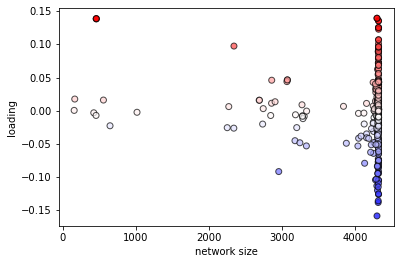

In [9]:
corr, p = spearman(xgroup2ns, xgroup2loadings)
print(f'network size vs. loading: corr = {corr}, p_value = {p}')

valid_keys, data1, data2 = todata(xgroup2ns, xgroup2loadings)
plt.scatter(data1, data2, marker='o',  c=data2, cmap='bwr', edgecolor='k', alpha=0.7, label='Data Points', zorder=2)
plt.xlabel('network size')
plt.ylabel('loading')
# plt.savefig('ns2loadings.png')
plt.show()

In [10]:
# which folds are on the left side? = 'important' folds
xgroup2nsSub1500 = {}
for xgroup in xgroup2ns:
    if xgroup2ns[xgroup] < 1500:
        xgroup2nsSub1500[xgroup] = xgroup2ns[xgroup]

print(xgroup2nsSub1500)

{'206': 454.0, '2002': 155.0, '325': 555.0, '4952': 457.0, '218': 163.0, '2005': 645.0, '2007': 423.0, '4953': 457.0, '2003': 1014.0, '602': 457.0}


In [11]:
# 'important' folds:

# 206: alpha + beta complex topology
# 218: "Enolase-N/ribosomal protein"
# 325: "alpha/beta-Hammerhead/Barrel-sandwich hybrid"
# 602: "L-aspartase middle domain-like"
# 2002: "TIM beta/alpha-barrel"
# 2003: "Rossmann-like"
# 2005: tRNA_synth related
# 2007: "Flavodoxin-like"
# 4952: no name
# 4953: no name

In [12]:
low_ns = set(xgroup2nsSub1500.keys())
print(low_ns)

{'206', '325', '2007', '2003', '2002', '602', '4952', '218', '4953', '2005'}


In [13]:
high_loading = set()
for x in xgroup2loadings:
    if xgroup2loadings[x] > 0.13:
        high_loading.add(x)
print(high_loading)

{'602', '4952', '7546', '7587', '4953', '7507', '4018'}


In [14]:
low_ns & high_loading

{'4952', '4953', '602'}

Looking at the bottom left corner of the graph, there are no folds with low loadings and low network size.

We also observe that not all 'important' folds with low network sizes have high loadings.

Three folds stand out: **602, 4952, 4953** have both high loadings and low network sizes.

- 602 is "L-aspartase middle domain-like". Proteins with this fold catalyze reversible deamination of amino acids.
- 4952 and 4953 are "No_X_NAME", but interestingly, their F_NAMEs are "L-aspartase N-terminal domain-like" and "L-aspartase C-terminal domain-like"

So these 3 folds come from the same protein, **L-aspartase**. There must be something about the ability to catalyze reversible deamination of amino acids that significantly restrict the size of the network AND makes the expansion process more susceptible to the starting set of compounds.

Think about the chemistry, too!  L-aspartase domain is part of aspartate ammonia-lyase.
Lyases would seem to be prevlidged because they do not require ATP to do important chemistry.  
If you have fold order information, can you check if Lyases (things that catalyze reactions associated with EC number 4) 
occur earlier than other folds?).  Back to this reaction, it is https://www.genome.jp/entry/4.3.1.1.  
This is the reaction that probably makes aspartate from ammonia and fumarate 
(these are both in the seed set, I think; you can actually check using the data you have). 
The other reactions to do this require ATP (see here: https://www.genome.jp/pathway/rn00250+R00490).  
And, as you can see, aspartate is a HUB of metabolism: https://www.genome.jp/entry/C00049

## divide in 2

In [15]:
high_l = {}
low_l = {}

for x in xgroup2loadings:
    if xgroup2loadings[x] > 0.05 or xgroup2loadings[x] < -0.05:
        high_l[x] = xgroup2rulesNum[x]
    else:
        low_l[x] = xgroup2rulesNum[x]

In [16]:
len(low_l), len(high_l)

(301, 96)

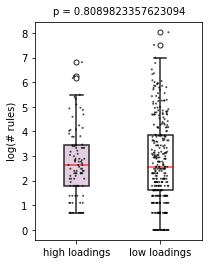

In [17]:
class1ds = np.array(list(high_l.values()))
class2ds = np.array(list(low_l.values()))

class1ds = np.log(class1ds)
class2ds = np.log(class2ds)

fig, ax = plt.subplots(figsize=(3, 4))

box_colors = ['purple', 'white']
# Use seaborn boxplot
boxplot = sns.boxplot(data=[class1ds, class2ds], width=0.3, ax=ax, palette=box_colors, medianprops=dict(color="red", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker="o"))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.2))

# data points
sns.stripplot(data=[class1ds, class2ds], color='black', size=2, jitter=True, ax=ax, alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(class1ds, class2ds)
#p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

plt.ylabel('log(# rules)')
ax.set_xticklabels(['high loadings', 'low loadings'])

# plt.savefig('boxplot_ds.png', bbox_inches='tight')
plt.show()

# network size vs. #rules
As mentione above,
we expect that leaving out folds with high rule counts would significantly reduce the network size.

Let's see if there is a negative correlation between the #rules and the network size.

*We also color each point (xgroup) by its corresponding loadings value*

network size vs. #rules: corr = -0.6035693134562072, p_value = 9.196312874064563e-41


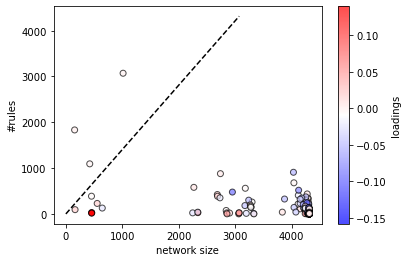

In [18]:
corr, p = spearman(xgroup2ns, xgroup2rulesNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')
scatterColor(xgroup2ns, xgroup2rulesNum, xgroup2loadings, 'network size', '#rules', 'loadings')

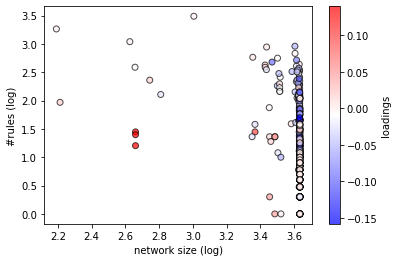

In [19]:
# Let's try loglog plot
loglogColor(xgroup2ns, xgroup2rulesNum, xgroup2loadings, 'network size (log)', '#rules (log)', 'loadings')

In [20]:
for xgroup in xgroup2nsSub1500:
    print(xgroup, xgroup2rulesNum[xgroup])

206 387.0
2002 1833.0
325 229.0
4952 25.0
218 93.0
2005 128.0
2007 1093.0
4953 16.0
2003 3071.0
602 28.0


Based on the spearman correlations and p-values, we do observe that there is a negative correlation between the #rules and the network size.

In particular, folds with the 3 largest # rules have networksizes less than 1500.
2002, 2003, 2007 are all a/b proteins. 2002 is TIM-barrel, and 2003 / 2007 are Rossmann-like and Flavodoxin-like folds with alpha-beta-alpha sandwich architecture.
They all bind cofactors (NAD, FAD, FMN) and catalyze a wide range of reactions.

# fold order (pre-expansion) vs. #rules

We expect 'early' folds with low fold order to also have high rule counts

fold order (NONE)vs. #rules: corr = -0.5028596211649818, p_value = 7.84770628920035e-27


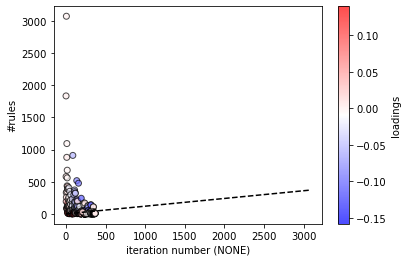

fold order (ALL) vs. #rules: corr = -0.7239677630722735, p_value = 1.1135930520465625e-65


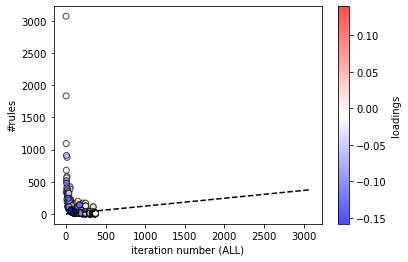

In [21]:
corr, p = spearman(xgroup2foAve['NONE'], xgroup2rulesNum)
print(f'fold order (NONE)vs. #rules: corr = {corr}, p_value = {p}')
scatterColor(xgroup2foAve['NONE'], xgroup2rulesNum, xgroup2loadings, 'iteration number (NONE)', '#rules', 'loadings')

corr, p = spearman(xgroup2foAve['ALL'], xgroup2rulesNum)
print(f'fold order (ALL) vs. #rules: corr = {corr}, p_value = {p}')
scatterColor(xgroup2foAve['ALL'], xgroup2rulesNum, xgroup2loadings, 'iteration number (ALL)', '#rules', 'loadings')

# indep instead of loadings
# scatterColor(xgroup2foAve['NONE'], xgroup2rulesNum, xgroup2indepNum, 'iteration number (NONE)', '#rules', 'indepNum')
# scatterColor(xgroup2foAve['ALL'], xgroup2rulesNum, xgroup2indepNum, 'iteration number (ALL)', '#rules', 'indepNum')
# scatterColor(xgroup2foAve['NONE'], xgroup2rulesNum, xgroup2indepFrac, 'iteration number (NONE)', '#rules', 'indepFrac')
# scatterColor(xgroup2foAve['ALL'], xgroup2rulesNum, xgroup2indepFrac, 'iteration number (ALL)', '#rules', 'indepFrac')

### Let's use ranks to improve visualization

In [22]:
# ranked #rules vs. average fold order

# no ties
# rulesNumRanks = {key: rank + 1 for rank, key in enumerate(reversed(sorted(xgroup2rulesNum, key=xgroup2rulesNum.get)))}
# neNONERanks = {key: rank + 1 for rank, key in enumerate((sorted(xgroup2foAve['NONE'], key=xgroup2foAve['NONE'].get)))}
# neALLRanks = {key: rank + 1 for rank, key in enumerate((sorted(xgroup2foAve['ALL'], key=xgroup2foAve['ALL'].get)))}

# with ties
# rulesNumRanks = {key: rank for key, rank in zip(xgroup2rulesNum.keys(), rankdata(list(xgroup2rulesNum.values()), method='min'))}
# neNONERanks = {key: rank for key, rank in zip(xgroup2foAve['NONE'].keys(), rankdata(list(xgroup2foAve['NONE'].values()), method='min'))}
# neALLRanks = {key: rank for key, rank in zip(xgroup2foAve['ALL'].keys(), rankdata(list(xgroup2foAve['ALL'].values()), method='min'))}

# with ties (x is reversed)
max_rank_x = max(rankdata(list(xgroup2rulesNum.values()), method='min'))
rulesNumRanksTie = {key: max_rank_x + 1 - rank for key, rank in zip(xgroup2rulesNum.keys(), rankdata(list(xgroup2rulesNum.values()), method='min'))}
neNONERanksTie = {key: rank for key, rank in zip(xgroup2foAve['NONE'].keys(), rankdata(list(xgroup2foAve['NONE'].values()), method='min'))}
neALLRanksTie = {key: rank for key, rank in zip(xgroup2foAve['ALL'].keys(), rankdata(list(xgroup2foAve['ALL'].values()), method='min'))}

fold order (NONE) RANKED vs. #rules RANKED: corr = 0.5028596211649818, p_value = 7.84770628920035e-27


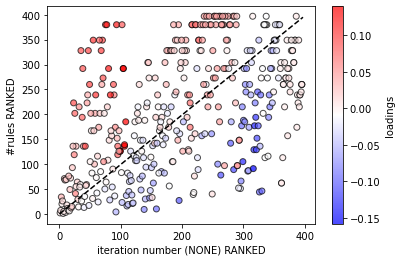

fold order (ALL) RANKED vs. #rules RANKED: corr = 0.7239677630722735, p_value = 1.1135930520465625e-65


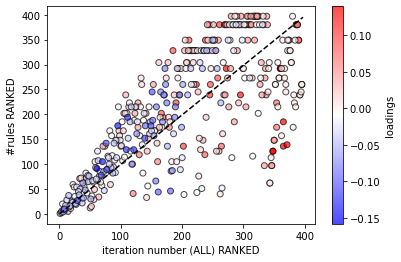

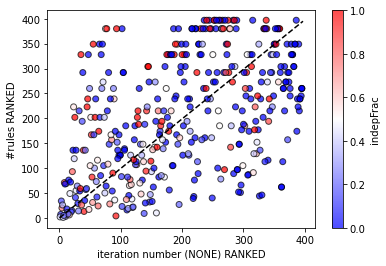

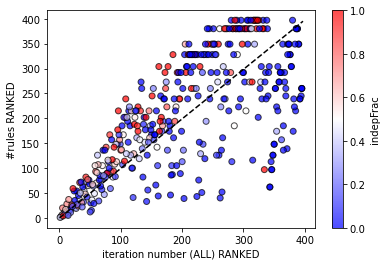

In [23]:
corr, p = spearman(neNONERanksTie, rulesNumRanksTie)
print(f'fold order (NONE) RANKED vs. #rules RANKED: corr = {corr}, p_value = {p}')
scatterColor(neNONERanksTie, rulesNumRanksTie, xgroup2loadings, 'iteration number (NONE) RANKED', '#rules RANKED', 'loadings')

corr, p = spearman(rulesNumRanksTie, neALLRanksTie)
print(f'fold order (ALL) RANKED vs. #rules RANKED: corr = {corr}, p_value = {p}')
scatterColor(neALLRanksTie, rulesNumRanksTie, xgroup2loadings, 'iteration number (ALL) RANKED', '#rules RANKED', 'loadings')

# # indep instead of loadings
# scatterColor(neNONERanksTie, rulesNumRanksTie, xgroup2indepNum, 'iteration number (NONE) RANKED', '#rules RANKED', 'indepNum')
# scatterColor(neALLRanksTie, rulesNumRanksTie, xgroup2indepNum, 'iteration number (ALL) RANKED', '#rules RANKED', 'indepNum')
scatterColor(neNONERanksTie, rulesNumRanksTie, xgroup2indepFrac, 'iteration number (NONE) RANKED', '#rules RANKED', 'indepFrac')
scatterColor(neALLRanksTie, rulesNumRanksTie, xgroup2indepFrac, 'iteration number (ALL) RANKED', '#rules RANKED', 'indepFrac')



## divide into above & below line

In [24]:
aboveNONE = {}
belowNONE = {}
for x in rulesNumRanksTie.keys():
    ratio = rulesNumRanksTie[x] / neNONERanksTie[x] 
    if ratio >= 1:
        aboveNONE[x] = ratio
    else:
        belowNONE[x] = ratio

In [25]:
aboveALL = {}
belowALL = {}
for x in rulesNumRanksTie.keys():
    ratio = rulesNumRanksTie[x] / neALLRanksTie[x]
    if ratio >= 1:
        aboveALL[x] = ratio
    else:
        belowALL[x] = ratio

In [26]:
len(belowNONE) + len(aboveNONE)  # 195 below + 202 above NONE

397

In [27]:
len(belowALL) + len(aboveALL)  # 151 below + 246 above ALL

397

### abs. req. (formerly called 'Independent')

In [28]:
xgroup2uniqueRnFraction = csv2dict('../data/assets/xgroup2/xgroup2uniqueRnFraction.csv')
xgroup2uniqueRnFraction.pop('spontaneous')

0.8795180722891566

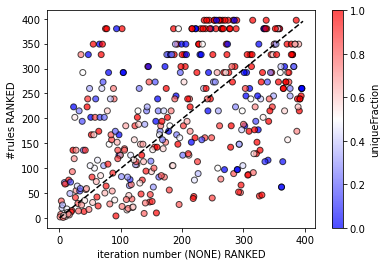

In [29]:
scatterColor(neNONERanksTie, rulesNumRanksTie, xgroup2uniqueRnFraction, 'iteration number (NONE) RANKED', '#rules RANKED', 'uniqueFraction')

### uniquely associated

In [30]:
# from fold2moduleKEGG.ipynb
SingleModuleX = {'7553': 'M00122', '4048': 'M00532', '136': 'M00043', '4004': 'M00100', '881': 'M00532', '300': 'M00093', '4022': 'M00045', '7500': 'M00346', '1055': 'M00877', '239': 'M00026', '7513': 'M00378', '875': 'M00022', '376': 'M00035', '158': 'M00113', '319': 'M00055', '102': 'M00053', '842': 'M00938', '4237': 'M00903', '3688': 'M00117', '4076': 'M00736', '374': 'M00418', '309': 'M00609', '148': 'M00529', '876': 'M00875', '185': 'M00114', '7551': 'M00358', '3001': 'M00016', '6096': 'M00124', '4126': 'M00065', '6051': 'M00776', '180': 'M00089', '4028': 'M00532', '258': 'M00017', '4019': 'M00893', '814': 'M00117', '528': 'M00055', '582': 'M00174', '3115': 'M00878', '303': 'M00133', '7504': 'M00938', '4160': 'M00622', '2010': 'M00344', '5084': 'M00867', '590': 'M00344', '214': 'M00130', '270': 'M00761', '3691': 'M00114', '3052': 'M00880', '3896': 'M00093', '4295': 'M00088', '7567': 'M00065', '601': 'M00089', '9': 'M00113', '869': 'M00567', '3754': 'M00055', '640': 'M00174', '199': 'M00047', '4021': 'M00975', '7536': 'M00346', '629': 'M00176', '4110': 'M00546'}

In [31]:
single2rulesNumRanks = {}
for x in SingleModuleX.keys():
    if x in set(aboveNONE.keys()):
        single2rulesNumRanks[x] = rulesNumRanksTie[x]

In [32]:
single2rulesNumRanks # len = 41

{'7553': 349,
 '4004': 185,
 '4022': 380,
 '7500': 328,
 '1055': 380,
 '239': 148,
 '7513': 292,
 '875': 380,
 '319': 292,
 '842': 380,
 '4237': 397,
 '3688': 167,
 '4076': 397,
 '309': 328,
 '876': 380,
 '185': 380,
 '7551': 380,
 '3001': 397,
 '6096': 397,
 '4126': 202,
 '6051': 328,
 '180': 136,
 '258': 292,
 '4019': 188,
 '814': 397,
 '582': 260,
 '3115': 380,
 '303': 349,
 '4160': 380,
 '590': 223,
 '270': 304,
 '3691': 292,
 '3896': 328,
 '4295': 397,
 '7567': 202,
 '869': 397,
 '3754': 194,
 '199': 328,
 '4021': 202,
 '7536': 328,
 '629': 328}

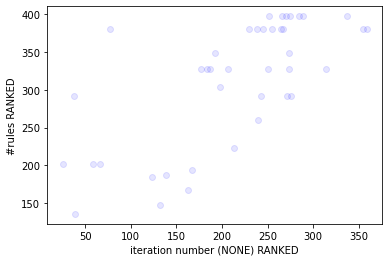

In [33]:
scatter(neNONERanksTie, single2rulesNumRanks, 'iteration number (NONE) RANKED', '#rules RANKED')

In [34]:
# hypothesis refuted.... RED dots (high loadings) ≠ "uniquely associated" folds

### draw bar plots

In [93]:
print(len(aboveNONE), len(belowNONE))
print(len(aboveALL), len(belowALL))

202 195
246 151


In [94]:
# NONE loadings
redBelow = []
blueBelow = []
redAbove = []
blueAbove = []

for x in belowNONE:
    if xgroup2loadings[x] >= 0:  # positive loading
        redBelow.append(x)
    else:
        blueBelow.append(x)
for x in aboveNONE:
    if xgroup2loadings[x] >= 0:  # positive loading
        redAbove.append(x)
    else:
        blueAbove.append(x)

In [95]:
print(len(redAbove), len(blueAbove), len(redBelow), len(blueBelow))

159 43 65 130


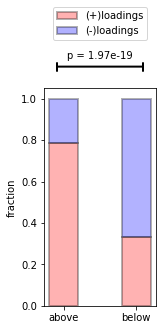

In [96]:
# NONE loadings
barplot2(['above', 'below'], [len(redAbove), len(redBelow)], [len(blueAbove), len(blueBelow)], label1='(+)loadings', label2='(-)loadings')

In [97]:
# ALL loadings
redBelow = []
blueBelow = []
redAbove = []
blueAbove = []

for x in belowALL:
    if xgroup2loadings[x] >= 0:  # positive loading
        redBelow.append(x)
    else:
        blueBelow.append(x)
for x in aboveALL:
    if xgroup2loadings[x] >= 0:  # positive loading
        redAbove.append(x)
    else:
        blueAbove.append(x)

In [98]:
print(len(redAbove), len(blueAbove), len(redBelow), len(blueBelow))

121 125 103 48


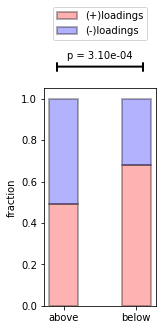

In [99]:
# ALL loadings
barplot2(['above', 'below'], [len(redAbove), len(redBelow)], [len(blueAbove), len(blueBelow)], label1='(+)loadings', label2='(-)loadings')

## indepFrac (50%)

In [100]:
# NONE indepFrac
redBelow = []
blueBelow = []
redAbove = []
blueAbove = []


for x in belowNONE:
    if xgroup2indepFrac[x] >= 0.5:  # higher fraction
        redBelow.append(x)
    else:
        blueBelow.append(x)
for x in aboveNONE:
    if xgroup2indepFrac[x] >= 0.5:  # higher fraction
        redAbove.append(x)
    else:
        blueAbove.append(x)

In [101]:
print(len(redAbove), len(blueAbove), len(redBelow), len(blueBelow))

68 134 44 151


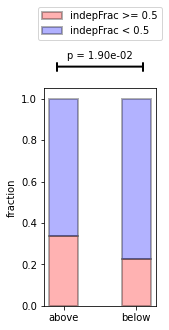

In [102]:
# NONE indepFrac
barplot2(['above', 'below'], [len(redAbove), len(redBelow)], [len(blueAbove), len(blueBelow)], label1='indepFrac >= 0.5', label2='indepFrac < 0.5', color1='red', color2='blue')

In [103]:
# ALL indepFrac
redBelow = []
blueBelow = []
redAbove = []
blueAbove = []


for x in belowALL:
    if xgroup2indepFrac[x] >= 0.5:  # higher fraction
        redBelow.append(x)
    else:
        blueBelow.append(x)
for x in aboveALL:
    if xgroup2indepFrac[x] >= 0.5:  # higher fraction
        redAbove.append(x)
    else:
        blueAbove.append(x)

In [104]:
print(len(redAbove), len(blueAbove), len(redBelow), len(blueBelow))

103 143 9 142


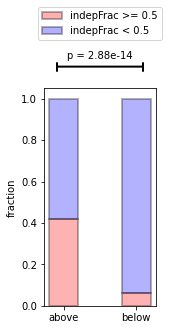

In [105]:
# ALL indepFrac
barplot2(['above', 'below'], [len(redAbove), len(redBelow)], [len(blueAbove), len(blueBelow)], label1='indepFrac >= 0.5', label2='indepFrac < 0.5', color1='red', color2='blue')

## Indep vs Aux

In [110]:
# NONE Indep vs. Aux
redBelow = []
blueBelow = []
redAbove = []
blueAbove = []


for x in belowNONE:
    if xgroup2indepFrac[x] > 0:  # Indep
        redBelow.append(x)
    else:
        blueBelow.append(x)  # Aux
for x in aboveNONE:
    if xgroup2indepFrac[x] > 0:  # Indep
        redAbove.append(x)
    else:
        blueAbove.append(x)  # Aux

In [111]:
print(len(redAbove), len(blueAbove), len(redBelow), len(blueBelow))

107 95 106 89


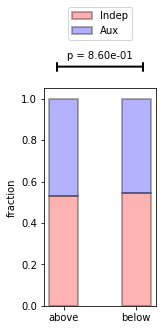

In [112]:
# NONE Indep vs. Aux
barplot2(['above', 'below'], [len(redAbove), len(redBelow)], [len(blueAbove), len(blueBelow)], label1='Indep', label2='Aux', color1='red', color2='blue')

In [113]:
# ALL Indep vs. Aux
redBelow = []
blueBelow = []
redAbove = []
blueAbove = []


for x in belowALL:
    if xgroup2indepFrac[x] > 0:  # Indep
        redBelow.append(x)
    else:
        blueBelow.append(x)  # Aux
for x in aboveALL:
    if xgroup2indepFrac[x] > 0:  # Indep
        redAbove.append(x)
    else:
        blueAbove.append(x)  # Aux

In [114]:
print(len(redAbove), len(blueAbove), len(redBelow), len(blueBelow))

155 91 58 93


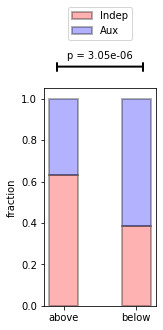

In [115]:
# NONE Indep vs. Aux
barplot2(['above', 'below'], [len(redAbove), len(redBelow)], [len(blueAbove), len(blueBelow)], label1='Indep', label2='Aux', color1='red', color2='blue')

## many_rules & early_folds

In [53]:
many_rules = set()
for x in xgroup2rulesNum:
    if xgroup2rulesNum[x] > 50:
        many_rules.add(x)
print(many_rules)

{'2007', '2003', '7524', '298', '1074', '219', '206', '136', '4011', '3323', '222', '179', '236', '12', '7577', '129', '4033', '7579', '109', '212', '7510', '223', '103', '2484', '314', '4294', '7522', '304', '213', '7515', '2487', '805', '107', '210', '7514', '244', '66', '211', '205', '2485', '7581', '7527', '331', '323', '7542', '376', '327', '5', '10', '131', '243', '7525', '3016', '149', '2005', '70', '2006', '102', '150', '11', '2002', '221', '141', '231', '2011', '101', '218', '1001', '7543', '279', '4', '159', '1', '4002', '6094', '325', '4052', '633', '2500', '7516', '2004', '7574', '217', '7512', '7584', '3321', '2486', '108', '301', '246'}


In [54]:
early_folds = set()
for x in xgroup2foAve['ALL']:
    if xgroup2foAve['ALL'][x] < 50:
        early_folds.add(x)
print(early_folds)

{'2484', '2007', '2003', '7522', '5', '304', '10', '131', '7524', '243', '805', '7525', '298', '206', '279', '210', '244', '159', '222', '149', '236', '2005', '1', '4002', '6094', '12', '7516', '129', '2004', '2006', '7581', '109', '7579', '7527', '212', '7574', '323', '217', '7510', '2002', '11', '7512', '221', '141', '2011', '101', '2486', '246'}


In [55]:
print(many_rules & early_folds)
print(sorted(map(int, many_rules & early_folds)))

{'2484', '2007', '2003', '7522', '5', '304', '10', '131', '7524', '243', '805', '7525', '298', '206', '279', '210', '244', '159', '222', '149', '236', '2005', '1', '4002', '6094', '12', '7516', '129', '2004', '2006', '7581', '109', '7579', '7527', '212', '7574', '323', '217', '7510', '2002', '11', '7512', '221', '141', '2011', '101', '2486', '246'}
[1, 5, 10, 11, 12, 101, 109, 129, 131, 141, 149, 159, 206, 210, 212, 217, 221, 222, 236, 243, 244, 246, 279, 298, 304, 323, 805, 2002, 2003, 2004, 2005, 2006, 2007, 2011, 2484, 2486, 4002, 6094, 7510, 7512, 7516, 7522, 7524, 7525, 7527, 7574, 7579, 7581]


Based on the spearman correlations and p-values, we do observe that there is a negative correlation between the #rules and the fold order.

**Earlier folds have more rules.**

There are folds in {many_rules & early_folds} set that are not 'important' folds for network size:

In [56]:
low_ns & many_rules & early_folds

{'2002', '2003', '2005', '2007', '206'}

In [57]:
# many_rules & early_folds NOT "important" 

# 1: "cradle loop barrel"
# 10: "jelly-roll"
# 11: "Immunoglobulin-like beta-sandwich"
# 12: "Glycosyl hydrolase domain-like"
# 101: "HTH"
# 109: "Repetitive alpha hairpins"
# 221: "beta-Grasp"
# 222: "Thioesterase/thiol ester dehydrase-isomerase-like"
# 244: "FAD-linked reductases, C-terminal domain-like"
# 304: "Alpha-beta plaits"

# 2004: "P-loop"


Some of these are very famous folds, like **"cradle loop barrel", "HTH"** and **"P-loop"**.

In [58]:
print(xgroup2ns['1'])
print(xgroup2ns['101'])
print(xgroup2ns['2004'])

2268.0
3240.0
2731.0


None of these attain the maximum network size of 4315.

But why do they still achieve network sizes >2,000? Are there other folds that can substitute? Are these folds partially 'redundant'?

# Unique reactions

Are things that are late but have a LOT of reactions characterized by a low fraction of unique reactions?

In [59]:
xgroup2uniqueRnNum = csv2dict('../data/assets/xgroup2/xgroup2uniqueRnNum.csv')
xgroup2uniqueRnNum.pop('spontaneous')
print(len(xgroup2uniqueRnNum))

xgroup2uniqueRnFraction = csv2dict('../data/assets/xgroup2/xgroup2uniqueRnFraction.csv')
xgroup2uniqueRnFraction.pop('spontaneous')
print(len(xgroup2uniqueRnFraction))

397
397


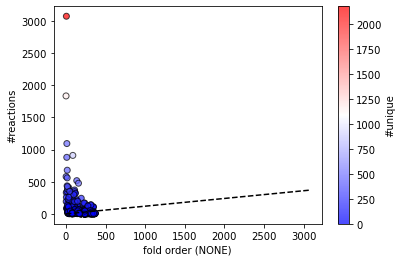

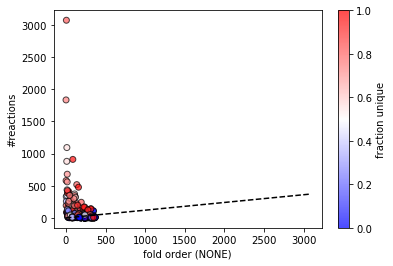

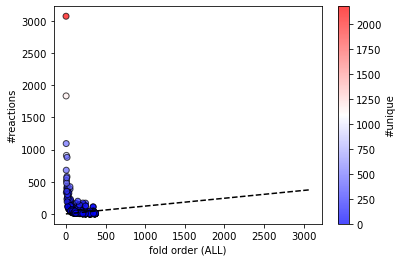

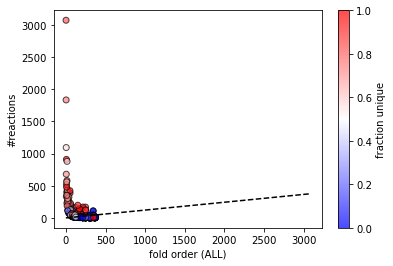

In [60]:
scatterColor(xgroup2foAve['NONE'], xgroup2rulesNum, xgroup2uniqueRnNum, 'fold order (NONE)', '#reactions', '#unique')
scatterColor(xgroup2foAve['NONE'], xgroup2rulesNum, xgroup2uniqueRnFraction, 'fold order (NONE)', '#reactions', 'fraction unique')

scatterColor(xgroup2foAve['ALL'], xgroup2rulesNum, xgroup2uniqueRnNum, 'fold order (ALL)', '#reactions',  '#unique')
scatterColor(xgroup2foAve['ALL'], xgroup2rulesNum, xgroup2uniqueRnFraction, 'fold order (ALL)', '#reactions',  'fraction unique')

In [61]:
xgroup2rulesNum['2003']

3071.0

In [62]:
xgroup2uniqueRnNum['2003']

2176.0

# ALL pre-expansion vs. #rules SRC

Let's see if pre-expansion sets have an influence on the correlation between fold_order and #rules

In [63]:
xgroup2foAve.keys()

dict_keys(['NONE', 'C00016', 'C00010', 'C00019', 'Z00009', 'ALL', 'C00002', 'Z00035', 'Z00047', 'C00004'])

In [64]:
corr, p = spearman(xgroup2rulesNum, xgroup2foAve['NONE'])
print(f'#rules vs. fold order (NONE): corr = {corr}, p_value = {p}')

corr, p = spearman(xgroup2rulesNum, xgroup2foAve['C00002'])
print(f'#rules vs. fold order (C00002): corr = {corr}, p_value = {p}')

corr, p = spearman(xgroup2rulesNum, xgroup2foAve['C00004'])
print(f'#rules vs. fold order (C00004): corr = {corr}, p_value = {p}')

corr, p = spearman(xgroup2rulesNum, xgroup2foAve['C00010'])
print(f'#rules vs. fold order (C00010): corr = {corr}, p_value = {p}')

corr, p = spearman(xgroup2rulesNum, xgroup2foAve['C00016'])
print(f'#rules vs. fold order (C00016): corr = {corr}, p_value = {p}')

corr, p = spearman(xgroup2rulesNum, xgroup2foAve['C00019'])
print(f'#rules vs. fold order (C00019): corr = {corr}, p_value = {p}')

corr, p = spearman(xgroup2rulesNum, xgroup2foAve['Z00009'])
print(f'#rules vs. fold order (Z00009): corr = {corr}, p_value = {p}')

corr, p = spearman(xgroup2rulesNum, xgroup2foAve['Z00035'])
print(f'#rules vs. fold order (Z00035): corr = {corr}, p_value = {p}')

corr, p = spearman(xgroup2rulesNum, xgroup2foAve['Z00047'])
print(f'#rules vs. fold order (Z00047): corr = {corr}, p_value = {p}')

corr, p = spearman(xgroup2rulesNum, xgroup2foAve['ALL'])
print(f'#rules vs. fold order (ALL): corr = {corr}, p_value = {p}')

#rules vs. fold order (NONE): corr = -0.5028596211649818, p_value = 7.84770628920035e-27
#rules vs. fold order (C00002): corr = -0.5892923788503712, p_value = 1.7437104252382984e-38
#rules vs. fold order (C00004): corr = -0.5860580952615617, p_value = 5.519631206386683e-38
#rules vs. fold order (C00010): corr = -0.581518638094565, p_value = 2.7220650277553637e-37
#rules vs. fold order (C00016): corr = -0.583631619736548, p_value = 1.299231759300602e-37
#rules vs. fold order (C00019): corr = -0.5791943024637178, p_value = 6.103017198891705e-37
#rules vs. fold order (Z00009): corr = -0.7187389639885339, p_value = 2.5054047314270848e-64
#rules vs. fold order (Z00035): corr = -0.5071997001329454, p_value = 2.4340663909784543e-27
#rules vs. fold order (Z00047): corr = -0.5931724744370572, p_value = 4.3016508070813736e-39
#rules vs. fold order (ALL): corr = -0.7239677630722735, p_value = 1.1135930520465625e-65


- ALL pre-expansion set has the strongest negative correlation, with the lowest p-value.
- Other sets have similar values except: Z00009 is similar to ALL; NONE and Z00035 are similar.

# #rules vs. loadings

The relationship between these variables is also less obvious.

#rules vs. loading: corr = -0.36362849050265106, p_value = 7.432669750099578e-14


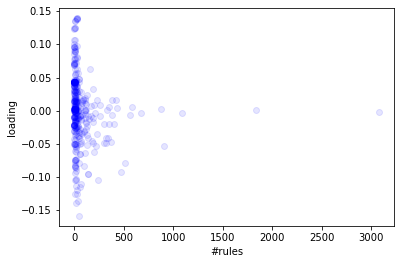

In [65]:
corr, p = spearman(xgroup2rulesNum, xgroup2loadings)
print(f'#rules vs. loading: corr = {corr}, p_value = {p}')
scatter(xgroup2rulesNum, xgroup2loadings, '#rules', 'loading')

- Loadings are normally distributed (as expected).

- Folds with many rules don't necesarily have high or low loadings.

- Can we say folds with high or low loadings have low #rules? That 'specialized' enzymes tend to have high or low loadings?

## box plot: fold order

In [66]:
# look at network size < 3600 and ≥ 3600

group1 = {}
group2 = {}
for xgroup in xgroup2ns:
    if xgroup2ns[xgroup] < 3600:
        group1[xgroup] = xgroup2ns[xgroup]
    else:
        group2[xgroup] = xgroup2ns[xgroup]

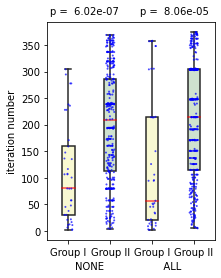

In [67]:
keys, data1, data2 = todata(xgroup2foAve['NONE'], group1) 
keys, data3, data4 = todata(xgroup2foAve['NONE'], group2) 
class1ds = np.array(data1)
class2ds = np.array(data3)

keys, data11, data22 = todata(xgroup2foAve['ALL'], group1) 
keys, data33, data44 = todata(xgroup2foAve['ALL'], group2) 
class11ds = np.array(data11)
class22ds = np.array(data33)

fig, ax = plt.subplots(figsize=(3, 4))

box_colors = ['yellow', 'green']
# Use seaborn boxplot
boxplot = sns.boxplot(data=[class1ds, class2ds, class11ds, class22ds], width=0.3, ax=ax, palette=box_colors, medianprops=dict(color="red", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker="o"))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.2))

# data points
sns.stripplot(data=[class1ds, class2ds, class11ds, class22ds], color='blue', size=2, jitter=True, ax=ax, alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(class1ds, class2ds)
p_value = f'{p_value: .2e}'
statisticALL, p_valueALL = mannwhitneyu(class11ds, class22ds)
p_valueALL = f'{p_valueALL: .2e}'
ax.annotate(f'p = {p_value}', xy=(0.22, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
ax.annotate(f'p = {p_valueALL}', xy=(0.76, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

plt.ylabel('iteration number')
ax.set_xticklabels(['Group I', 'Group II', 'Group I', 'Group II'])
plt.xlabel('NONE                   ALL  ')

# plt.savefig('boxplot_fo_NONE_and_ALL.png', bbox_inches='tight')
plt.show()

## TOTEM POLE: p-value comparison

In [68]:
ab_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv'
xgroup2ds_ab = csv2dict(ab_path)
print(len(xgroup2ds_ab))

rep_path = '../data/assets/xgroup2/xgroup2repetitiveness_v1.json'
with open(rep_path, 'r') as file:
    xgroup2rep = json.load(file)
print(len(xgroup2rep))

2230
379


In [69]:
xgroup2foAve.keys()

dict_keys(['NONE', 'C00016', 'C00010', 'C00019', 'Z00009', 'ALL', 'C00002', 'Z00035', 'Z00047', 'C00004'])

In [70]:
# 'NONE', 'C00016', 'C00010', 'C00019', 'Z00009', 'ALL', 'C00002', 'Z00035', 'Z00047', 'C00004'
#           FAD       CoA       SAM     Cobalamin          ATP       PLP       ThDP       NADH

# NONE/PLP
# ATP/NADH
# CoA/FAD/SAM/ThDP ('thiamine' diphosphate)
# ALL/Cobalamin

In [71]:
# ds
ds_p_list = []
corr, p = spearman(xgroup2ds_ab, xgroup2foAve['NONE'])
print(f'dist score vs. fold order (NONE): corr = {corr}, p_value = {p}')
ds_p_list.append(p)

corr, p = spearman(xgroup2ds_ab, xgroup2foAve['C00002'])  # ATP
print(f'dist score vs. fold order (C00002): corr = {corr}, p_value = {p}')
ds_p_list.append(p)

corr, p = spearman(xgroup2ds_ab, xgroup2foAve['C00010'])  # CoA
print(f'dist score vs. fold order (C00010): corr = {corr}, p_value = {p}')
ds_p_list.append(p)

corr, p = spearman(xgroup2ds_ab, xgroup2foAve['ALL'])
print(f'dist score vs. fold order (ALL): corr = {corr}, p_value = {p}')
ds_p_list.append(p)

dist score vs. fold order (NONE): corr = -0.5133394687015972, p_value = 4.51384975618518e-28
dist score vs. fold order (C00002): corr = -0.5406201222223422, p_value = 1.6470333711228813e-31
dist score vs. fold order (C00010): corr = -0.5308496235104345, p_value = 3.0476068074744113e-30
dist score vs. fold order (ALL): corr = -0.4832695072081582, p_value = 1.2626400818429848e-24


In [72]:
ds_p_list

[4.51384975618518e-28,
 1.6470333711228813e-31,
 3.0476068074744113e-30,
 1.2626400818429848e-24]

In [73]:
# repetitiveness
rep_p_list = []
corr, p = spearman(xgroup2rep, xgroup2foAve['NONE'])
print(f'repetitiveness vs. fold order (NONE): corr = {corr}, p_value = {p}')
rep_p_list.append(p)

corr, p = spearman(xgroup2rep, xgroup2foAve['C00002'])
print(f'repetitiveness vs. fold order (C00002): corr = {corr}, p_value = {p}')
rep_p_list.append(p)

corr, p = spearman(xgroup2rep, xgroup2foAve['C00010'])
print(f'repetitiveness vs. fold order (C00010): corr = {corr}, p_value = {p}')
rep_p_list.append(p)

corr, p = spearman(xgroup2rep, xgroup2foAve['ALL'])
print(f'repetitiveness vs. fold order (ALL): corr = {corr}, p_value = {p}')
rep_p_list.append(p)

repetitiveness vs. fold order (NONE): corr = -0.04483711057514253, p_value = 0.5062930098485734
repetitiveness vs. fold order (C00002): corr = -0.042877142773823554, p_value = 0.5250757059226316
repetitiveness vs. fold order (C00010): corr = -0.06257945427957617, p_value = 0.3533768965655404
repetitiveness vs. fold order (ALL): corr = -0.07464872671344373, p_value = 0.2680743367092463


In [74]:
rep_p_list

[0.5062930098485734,
 0.5250757059226316,
 0.3533768965655404,
 0.2680743367092463]

In [75]:
# numRules
numRules_p_list = []
corr, p = spearman(xgroup2rulesNum, xgroup2foAve['NONE'])
print(f'#rules vs. fold order (NONE): corr = {corr}, p_value = {p}')
numRules_p_list.append(p)

corr, p = spearman(xgroup2rulesNum, xgroup2foAve['C00002'])
print(f'#rules vs. fold order (C00002): corr = {corr}, p_value = {p}')
numRules_p_list.append(p)

corr, p = spearman(xgroup2rulesNum, xgroup2foAve['C00010'])
print(f'#rules vs. fold order (C00010): corr = {corr}, p_value = {p}')
numRules_p_list.append(p)

corr, p = spearman(xgroup2rulesNum, xgroup2foAve['ALL'])
print(f'#rules vs. fold order (ALL): corr = {corr}, p_value = {p}')
numRules_p_list.append(p)

#rules vs. fold order (NONE): corr = -0.5028596211649818, p_value = 7.84770628920035e-27
#rules vs. fold order (C00002): corr = -0.5892923788503712, p_value = 1.7437104252382984e-38
#rules vs. fold order (C00010): corr = -0.581518638094565, p_value = 2.7220650277553637e-37
#rules vs. fold order (ALL): corr = -0.7239677630722735, p_value = 1.1135930520465625e-65


In [76]:
numRules_p_list

[7.84770628920035e-27,
 1.7437104252382984e-38,
 2.7220650277553637e-37,
 1.1135930520465625e-65]

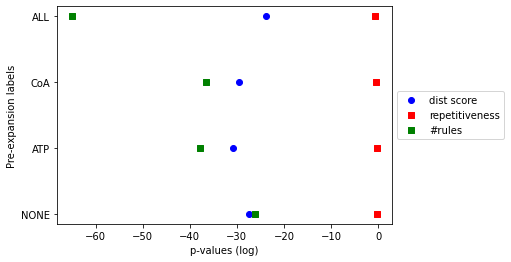

In [77]:
categories_set1 = ['NONE', 'ATP', 'CoA', 'ALL']
values_set1 = ds_p_list
indices_set1 = np.arange(len(categories_set1))

categories_set2 = ['NONE', 'ATP', 'CoA', 'ALL']
values_set2 = rep_p_list
indices_set2 = np.arange(len(categories_set2))

categories_set3 = ['NONE', 'ATP/NADH', 'CoA', 'ALL']
values_set3 = numRules_p_list
indices_set3 = np.arange(len(categories_set3))

# plot
plt.scatter(np.log10(values_set1), indices_set1, color='blue', marker='o', label='dist score')
plt.scatter(np.log10(values_set2), indices_set2, color='red', marker='s', label='repetitiveness')
plt.scatter(np.log10(values_set3), indices_set3, color='green', marker='s', label='#rules')

# Adding labels and title
plt.xlabel('p-values (log)')
plt.yticks(np.arange(len(categories_set1)), categories_set1)
plt.ylabel('Pre-expansion labels')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# plt.savefig('3D_totem.png', bbox_inches='tight')
plt.show()

## take average per cluster (4), not per label (10)

In [78]:
# 'NONE', 'C00016', 'C00010', 'C00019', 'Z00009', 'ALL', 'C00002', 'Z00035', 'Z00047', 'C00004'
#           FAD       CoA       SAM     Cobalamin          ATP       PLP       ThDP       NADH

In [79]:
# import pre-expansion fold orders
with open(ne_path, 'r') as file:
    lines = file.readlines()
 
xgroup2foAveCluster = {'NONE/PLP': {}, 'ATP/NADH': {}, 'CoA/FAD/SAM/ThDP': {}, 'ALL/Cobalamin': {}}
for line in lines:
    if line[0] == ',':
        header = line.split(',')[3:-3]
        continue

    data = list(map(int,line.split(',')[3:-3]))
    pre = line.split(',')[-1].strip()
    
    # check each xgroup
    for i in range(len(header)):
        xgroup = header[i]
        fo = data[i]
        
        # divide according to cluster, not pre            
        if pre == 'NONE' or pre == 'Z00035':
            cluster = 'NONE/PLP'
        elif pre == 'C00002' or pre == 'C00004':
            cluster = 'ATP/NADH'
        elif pre == 'ALL' or pre == 'Z00009':
            cluster = 'ALL/Cobalamin'
        else:
            cluster = 'CoA/FAD/SAM/ThDP'

        if xgroup not in xgroup2foAveCluster[cluster]:  # first time
            xgroup2foAveCluster[cluster][xgroup] = [fo]  
        else:
            xgroup2foAveCluster[cluster][xgroup].append(fo)  # the rest

# take average within each cluster
for cluster in xgroup2foAveCluster:
    for xgroup in xgroup2foAveCluster[cluster]:
        xgroup2foAveCluster[cluster][xgroup] = np.mean(xgroup2foAveCluster[cluster][xgroup])

In [80]:
xgroup2foAveCluster['NONE/PLP']

{'2002': 2.0,
 '1': 3.5,
 '2487': 9.7535,
 '2006': 4.0,
 '2003': 5.7555,
 '246': 9.2445,
 '7525': 9.904,
 '218': 19.997,
 '2007': 9.222,
 '304': 9.8055,
 '12': 12.241,
 '11': 13.241,
 '109': 14.8595,
 '10': 12.1225,
 '210': 13.7615,
 '7515': 17.2325,
 '279': 18.9775,
 '7577': 21.226,
 '3016': 22.226,
 '281': 23.3525,
 '7528': 24.61,
 '331': 25.61,
 '7542': 19.53,
 '301': 27.7405,
 '7572': 27.963,
 '2011': 23.719,
 '325': 29.8905,
 '206': 30.4145,
 '282': 32.168,
 '7527': 25.333,
 '805': 25.319,
 '7529': 38.135,
 '7512': 38.1735,
 '3691': 38.143,
 '7518': 31.016,
 '7579': 35.393,
 '62': 31.2965,
 '4126': 31.5155,
 '7560': 38.077,
 '180': 38.0395,
 '7554': 46.2505,
 '315': 46.164,
 '70': 46.188,
 '297': 46.0475,
 '7580': 48.934,
 '4002': 45.966,
 '286': 46.219,
 '2004': 48.8645,
 '205': 46.317,
 '7561': 58.754,
 '7517': 60.909,
 '7574': 58.9025,
 '387': 58.9025,
 '7571': 58.861,
 '5': 45.21,
 '247': 58.9105,
 '7567': 58.7915,
 '212': 59.0505,
 '7510': 58.9395,
 '5104': 58.825,
 '307': 58

In [81]:
# ds
ds_p_list = []
corr, p = spearman(xgroup2ds_ab, xgroup2foAveCluster['NONE/PLP'])
print(f'dist score vs. fold order (NONE/PLP): corr = {corr}, p_value = {p}')
ds_p_list.append(p)

corr, p = spearman(xgroup2ds_ab, xgroup2foAveCluster['ATP/NADH'])  
print(f'dist score vs. fold order (ATP/NADH): corr = {corr}, p_value = {p}')
ds_p_list.append(p)

corr, p = spearman(xgroup2ds_ab, xgroup2foAveCluster['CoA/FAD/SAM/ThDP'])
print(f'dist score vs. fold order (CoA/FAD/SAM/ThDP): corr = {corr}, p_value = {p}')
ds_p_list.append(p)

corr, p = spearman(xgroup2ds_ab, xgroup2foAveCluster['ALL/Cobalamin'])
print(f'dist score vs. fold order (ALL/Cobalamin): corr = {corr}, p_value = {p}')
ds_p_list.append(p)

dist score vs. fold order (NONE/PLP): corr = -0.5150200344746362, p_value = 2.8290619487574015e-28
dist score vs. fold order (ATP/NADH): corr = -0.5416047272663856, p_value = 1.220920137419292e-31
dist score vs. fold order (CoA/FAD/SAM/ThDP): corr = -0.5288213713411695, p_value = 5.519424708687483e-30
dist score vs. fold order (ALL/Cobalamin): corr = -0.48825503113388985, p_value = 3.573988823418429e-25


In [82]:
ds_p_list

[2.8290619487574015e-28,
 1.220920137419292e-31,
 5.519424708687483e-30,
 3.573988823418429e-25]

In [83]:
# repetitiveness
rep_p_list = []
corr, p = spearman(xgroup2rep, xgroup2foAveCluster['NONE/PLP'])
print(f'repetitiveness vs. fold order (NONE): corr = {corr}, p_value = {p}')
rep_p_list.append(p)

corr, p = spearman(xgroup2rep, xgroup2foAveCluster['ATP/NADH'])
print(f'repetitiveness vs. fold order (ATP/NADH): corr = {corr}, p_value = {p}')
rep_p_list.append(p)

corr, p = spearman(xgroup2rep, xgroup2foAveCluster['CoA/FAD/SAM/ThDP'])
print(f'repetitiveness vs. fold order (CoA/FAD/SAM/ThDP): corr = {corr}, p_value = {p}')
rep_p_list.append(p)

corr, p = spearman(xgroup2rep, xgroup2foAveCluster['ALL/Cobalamin'])
print(f'repetitiveness vs. fold order (ALL): corr = {corr}, p_value = {p}')
rep_p_list.append(p)

repetitiveness vs. fold order (NONE): corr = -0.05350460296185302, p_value = 0.42762133079866926
repetitiveness vs. fold order (ATP/NADH): corr = -0.04272964516847691, p_value = 0.5265033951475984
repetitiveness vs. fold order (CoA/FAD/SAM/ThDP): corr = -0.05966590402411884, p_value = 0.37627969476274836
repetitiveness vs. fold order (ALL): corr = -0.07555683054706014, p_value = 0.2622796339129001


In [84]:
rep_p_list

[0.42762133079866926,
 0.5265033951475984,
 0.37627969476274836,
 0.2622796339129001]

In [85]:
# numRules
numRules_p_list = []
corr, p = spearman(xgroup2rulesNum, xgroup2foAveCluster['NONE/PLP'])
print(f'#rules vs. fold order (NONE/PLP): corr = {corr}, p_value = {p}')
numRules_p_list.append(p)

corr, p = spearman(xgroup2rulesNum, xgroup2foAveCluster['ATP/NADH'])
print(f'#rules vs. fold order (ATP/NADH): corr = {corr}, p_value = {p}')
numRules_p_list.append(p)

corr, p = spearman(xgroup2rulesNum, xgroup2foAveCluster['CoA/FAD/SAM/ThDP'])
print(f'#rules vs. fold order (CoA/FAD/SAM/ThDP): corr = {corr}, p_value = {p}')
numRules_p_list.append(p)

corr, p = spearman(xgroup2rulesNum, xgroup2foAveCluster['ALL/Cobalamin'])
print(f'#rules vs. fold order (ALL/Cobalamin): corr = {corr}, p_value = {p}')
numRules_p_list.append(p)

#rules vs. fold order (NONE/PLP): corr = -0.5050141759351064, p_value = 4.398059999224451e-27
#rules vs. fold order (ATP/NADH): corr = -0.5863479958350474, p_value = 4.980616134002339e-38
#rules vs. fold order (CoA/FAD/SAM/ThDP): corr = -0.589354628186945, p_value = 1.705247214818207e-38
#rules vs. fold order (ALL/Cobalamin): corr = -0.7231855575177982, p_value = 1.7823010638051322e-65


In [86]:
numRules_p_list

[4.398059999224451e-27,
 4.980616134002339e-38,
 1.705247214818207e-38,
 1.7823010638051322e-65]

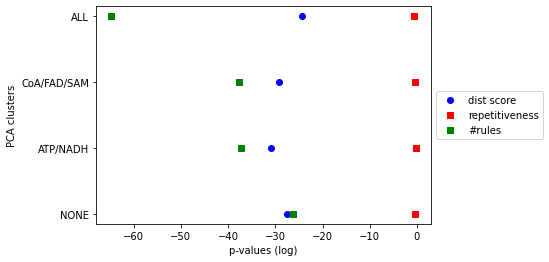

In [87]:
categories_set1 = ['NONE', 'ATP/NADH', 'CoA/FAD/SAM', 'ALL']
values_set1 = ds_p_list
indices_set1 = np.arange(len(categories_set1))

categories_set2 = ['NONE', 'ATP/NADH', 'CoA/FAD/SAM', 'ALL']
values_set2 = rep_p_list
indices_set2 = np.arange(len(categories_set2))

categories_set3 = ['NONE', 'ATP/NADH', 'CoA/FAD/SAM', 'ALL']
values_set3 = numRules_p_list
indices_set3 = np.arange(len(categories_set3))

# plot
plt.scatter(np.log10(values_set1), indices_set1, color='blue', marker='o', label='dist score')
plt.scatter(np.log10(values_set2), indices_set2, color='red', marker='s', label='repetitiveness')
plt.scatter(np.log10(values_set3), indices_set3, color='green', marker='s', label='#rules')

# Adding labels and title
plt.xlabel('p-values (log)')
plt.yticks(np.arange(len(categories_set1)), categories_set1)
plt.ylabel('PCA clusters')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# plt.savefig('3D_totem.png', bbox_inches='tight')
plt.show()